In [1]:
import pandas as pd

df = pd.read_excel('Result_28.xlsx')

In [2]:
import pandas as pd

# Ler arquivo
df = pd.read_excel('Result_28.xlsx')

# Lista de colaboradores
colaboradores = [
    'Rodolfo',
    'Wenderson do nascimento',
    'Wilhard',
    'Pedro',
    'Renan',
    'Mirian',
    'Joao Victor',
    'José',
    'Endrew',
    'Jeferson',
    'Isabella'
]

# Filtrar Nova Solicitação + colaboradores desejados
df_filtrado = df[
    (df['categoria'].astype(str).str.strip().str.lower() == 'nova solicitação'.lower())
    &
    (df['colaborador'].astype(str).str.strip().isin(colaboradores))
]

# Salvar resultado
df_filtrado.to_excel('Nova_Solicitacao_Colaboradores.xlsx', index=False)

print(f'{len(df_filtrado)} tickets encontrados.')

4258 tickets encontrados.


In [3]:
if __name__ == "__main__":

    print("Valores nulos restantes por coluna:")
    print(df.isnull().sum())

Valores nulos restantes por coluna:
tipo_ticket                0
problema_nosso         21673
servico                19997
meio                       0
status_cliente             0
categoria               2440
hist                   19214
codcli                     0
consultor                  4
classificacao              0
data_criacao_ticket        0
id_ticket                  0
titulo                    11
colaborador            26703
data_atualizacao           0
duracao                47016
mensagem                2919
dtype: int64


In [4]:
# 1. Tratamento do tempo e criação da coluna de minutos
df["duracao"] = df["duracao"].fillna("00:00:00")
df["duracao"] = pd.to_timedelta(df["duracao"], errors="coerce")
df["data_atualizacao"] = pd.to_datetime(df["data_atualizacao"], errors="coerce")

# Converter durações para formato HH:MM:SS (string) removendo 'days'
df['duracao_minutos_individual'] = df['duracao'].astype(str).str.replace(r'^(\d+ days?\s+)?', '', regex=True).str.split('.').str[0]

# 2. Somar a duração por ticket e criar coluna separada
df['duracao_minutos_total_por_ticket'] = df.groupby('id_ticket')['duracao'].transform('sum').astype(str).str.split('.').str[0]


# 3. Lista de colunas que NÃO queremos que o preenchimento automático toque
# (duracao já está preenchida, mensagem não será alterada, id_ticket é a chave)
colunas_ignoradas = ['id_ticket', 'duracao', 'duracao_minutos_individual', 'mensagem', 'duracao_minutos_total_por_ticket']

# Criar a lista de colunas para preencher (todas as outras colunas)
colunas_para_preencher = [col for col in df.columns if col not in colunas_ignoradas]

# 4. Preencher as lacunas em bloco (bfill e ffill) para cada ticket
df[colunas_para_preencher] = df.groupby('id_ticket')[colunas_para_preencher].transform(
    lambda x: x.bfill().ffill()
)
# 5. Remover a coluna de duração original, pois agora temos as colunas de minutos
df = df.drop('duracao', axis=1)

# 6. Remover os status pendentes, pois não são mais relevantes para a análise
df = df[df["status_cliente"].isin(["FECHADO"])]
df = df.dropna(subset=["status_cliente"])

# 7. Preencher valores nulos na coluna "problema_nosso"
df["problema_nosso"] = df["problema_nosso"].fillna("Indefinido", inplace= True)

# 8. Preencher valores nulos na coluna "servico"
df['servico'] = df['servico'].fillna("Serviço Indefinido", inplace= True)

# 9. Preencher valores nulos na coluna "categoria"
df['categoria'] = df['categoria'].fillna("Categoria Indefinida", inplace= True)

# 10. Preencher valores nulos na coluna "hist"
df['hist'] = df['hist'].fillna("Versão Indefinido", inplace= True)

# 11. Preencher valores nulos na coluna "consultor"
df['consultor'] = df['consultor'].fillna("Indefinido", inplace= True)

# 12. Preencher valores nulos na coluna "titulo"
df['titulo'] = df['titulo'].fillna("Sem título", inplace= True)

# 13. Preencher valores nulos na coluna "colaborador"
df['colaborador'] = df['colaborador'].fillna("Colaborador Indefinido", inplace= True)

# 14. Preencher valores nulos na coluna "data_atualizacao"
df['data_atualizacao'] = df['data_atualizacao'].fillna("00:00:00")

# 15. Preencher valores nulos na coluna "mensagem" e limpar caracteres de quebra de linha
df['mensagem'] = df['mensagem'].fillna("Sem mensagem", inplace= True)
# Remove "mailto:"
df["mensagem"] = df["mensagem"].str.replace("mailto:", "", regex=False)
# Remove emails
df["mensagem"] = df["mensagem"].str.replace(
    r'\S+@\S+',
    '',
    regex=True
)
# Remove entidades HTML &nbsp;
df["mensagem"] = df["mensagem"].str.replace("&nbsp;", " ", regex=False)
# Remove espaços extras novamente
df["mensagem"] = df["mensagem"].str.replace(r'\s+', ' ', regex=True).str.strip()

# 16. Ordenar categoria por ordem alfabética
ordem = ["A", "B", "C"]

df["classificacao"] = pd.Categorical(
    df["classificacao"],
    categories=ordem,
    ordered=True
)

df = df.sort_values("classificacao")


if __name__ == "__main__":

    print("Valores nulos restantes por coluna:")
    print(df.isnull().sum())

C:\Users\44275289889\AppData\Local\Temp\ipykernel_31836\1743789501.py:32: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["problema_nosso"] = df["problema_nosso"].fillna("Indefinido", inplace= True)
C:\Users\44275289889\AppData\Local\Temp\ipykernel_31836\1743789501.py:35: ChainedAssignmentError: A value is being set on a copy of a D

Valores nulos restantes por coluna:
tipo_ticket                         0
problema_nosso                      0
servico                             0
meio                                0
status_cliente                      0
categoria                           0
hist                                0
codcli                              0
consultor                           0
classificacao                       0
data_criacao_ticket                 0
id_ticket                           0
titulo                              0
colaborador                         0
data_atualizacao                    0
mensagem                            0
duracao_minutos_individual          0
duracao_minutos_total_por_ticket    0
dtype: int64


In [5]:
df

,tipo_ticket,problema_nosso,servico,meio,status_cliente,categoria,hist,codcli,consultor,classificacao,data_criacao_ticket,id_ticket,titulo,colaborador,data_atualizacao,mensagem,duracao_minutos_individual,duracao_minutos_total_por_ticket
43108,suporte,Indefinido,Serviço Indefinido,Portal Cliente,FECHADO,Nova Solicitação,Versão Indefinido,5463,Julio Cesar,A,2025-06-09 04:55,358272,Liberar site,Cleverton,2025-06-09 04:55:00,Liberar site,00:00:00,0 days 00:03:12
90135,suporte,SIM,Fortinet,Portal Cliente,FECHADO,Nova Solicitação,Fortigate 40F s/ lic - Palmas Embrasil,4968,Janaina,A,2025-11-07 11:55,371606,Embrasil - Palmas Voip 3cx,João Paulo,2025-11-07 01:55:00,"Prezados, boa tarde.Configuração realizada par...",00:07:09,0 days 00:07:09
39400,suporte,SIM,Fortinet,Portal Cliente,FECHADO,Nova Solicitação,Fortigate 80F,2286,Janaina,A,2025-05-28 04:55,357296,Incluir servidores na regra do anydesk,Lucas,2025-05-28 04:55:00,Incluir servidores na regra do anydesk,00:00:00,0 days 00:17:00
39401,suporte,SIM,Fortinet,Portal Cliente,FECHADO,Nova Solicitação,Fortigate 80F,2286,Janaina,A,2025-05-28 04:55,357296,Incluir servidores na regra do anydesk,Lucas,2025-05-28 04:55:00,"Prezados,Boa tarde.Preciso que seja incluído n...",00:00:00,0 days 00:17:00
39402,suporte,SIM,Fortinet,Portal Cliente,FECHADO,Nova Solicitação,Fortigate 80F,2286,Janaina,A,2025-05-28 04:55,357296,Incluir servidores na regra do anydesk,Lucas,2025-05-28 05:55:00,"Navito, boa tarde!Conforme as regras criadas a...",00:04:42,0 days 00:17:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56537,suporte,SIM,Acesso Dedicado,WhatsApp,FECHADO,Problema,Rompimento,6075,CTI-ADM,C,2025-07-28 08:55,362043,Rompimento - MKT LOG - 28/07/2025,Allan,2025-07-28 03:55:00,Sem mensagem,00:00:37,0 days 00:07:14
56536,suporte,SIM,Acesso Dedicado,WhatsApp,FECHADO,Problema,Rompimento,6075,CTI-ADM,C,2025-07-28 08:55,362043,Rompimento - MKT LOG - 28/07/2025,Allan,2025-07-28 08:55:00,Estamos com um rompimento no trecho acima cons...,00:01:12,0 days 00:07:14
56535,suporte,SIM,Acesso Dedicado,WhatsApp,FECHADO,Problema,Rompimento,6075,CTI-ADM,C,2025-07-28 08:55,362043,Rompimento - MKT LOG - 28/07/2025,Allan,2025-07-28 08:55:00,Rompimento - MKT LOG - 28/07/2025,00:00:00,0 days 00:07:14
56531,suporte,SIM,Acesso Dedicado,WhatsApp,FECHADO,Nova Solicitação,Rompimento,4873,CTI-ADM,C,2025-07-26 01:55,362033,Rompimento - 5557-SMARTS_AVENIDA_POMPEIA-LD e ...,Ermerson,2025-07-26 07:55:00,"https://maps.google.com/?q=-23.5274437,-46.683...",00:03:24,0 days 00:40:30


In [6]:
# Criar tabela separada com minutos totais de resolução por serviço (apenas FECHADO, NÃO altera `df`)
import pandas as pd
# Ler novamente a fonte bruta e manter apenas status FECHADO
df_raw = pd.read_excel('Result_28.xlsx')
if 'status_cliente' in df_raw.columns:
    df_raw = df_raw[df_raw['status_cliente'] == 'FECHADO']
# Garantir coluna de duração como timedelta (tenta usar coluna total por ticket se existir)
if 'duracao_minutos_total_por_ticket' in df_raw.columns:
    df_raw['duracao_td'] = pd.to_timedelta(df_raw['duracao_minutos_total_por_ticket'], errors='coerce')
else:
    df_raw['duracao'] = df_raw['duracao'].fillna('00:00:00')
    df_raw['duracao_td'] = pd.to_timedelta(df_raw['duracao'], errors='coerce')
# Agregar por ticket para obter duração total por ticket e o serviço associado
ticket_tot = df_raw.groupby('id_ticket').agg({'servico':'first', 'duracao_td':'sum'}).reset_index()
# Converter para minutos numéricos
ticket_tot['duracao_minutos'] = ticket_tot['duracao_td'].dt.total_seconds() / 60
# Somar minutos por serviço (tabela separada)
tabela_total_por_servico = ticket_tot.groupby('servico', dropna=False)['duracao_minutos'].sum().reset_index().rename(columns={'duracao_minutos':'total_minutos'})
tabela_total_por_servico = tabela_total_por_servico.sort_values('total_minutos', ascending=False).reset_index(drop=True)
# Exibir a tabela e deixá-la disponível como variável
print('Tabela de minutos totais por serviço (apenas FECHADO, sem alterar `df`):')
print(tabela_total_por_servico)
# A variável `tabela_total_por_servico` está disponível para uso posterior

Tabela de minutos totais por serviço (apenas FECHADO, sem alterar `df`):
                    servico  total_minutos
0                  Fortinet  203025.550000
1           Acesso Dedicado  185028.650000
2                    E-mail   33675.766667
3                    Backup   27996.450000
4                 Antivirus   22450.950000
5                Hospedagem   16221.683333
6                 SonicWall   14713.216667
7     Cloud - Serv. Virtual   12436.750000
8                       NaN   11076.400000
9                     WiFi+   10736.850000
10               Trust-Mail    2155.633333
11                     SMTP    2085.883333
12     Acesso Link Comercio    1990.883333
13     Suporte a servidores    1632.516667
14                 Antispam    1400.950000
15              Co-Location     404.400000
16  Analise Vulnerabilidade     172.133333
17                   ZABBIX     151.100000
18                      FTP      12.583333


In [7]:
# Calcular tabela média de minutos por serviço (apenas FECHADO, sem alterar `df`)
import pandas as pd
# Reutiliza `ticket_tot` se existir; garante que use apenas tickets FECHADO
try:
    ticket_for_avg = ticket_tot.copy()
    if 'status_cliente' in ticket_for_avg.columns:
        ticket_for_avg = ticket_for_avg[ticket_for_avg['status_cliente'] == 'FECHADO']
except NameError:
    df_raw = pd.read_excel('Result_28.xlsx')
    if 'status_cliente' in df_raw.columns:
        df_raw = df_raw[df_raw['status_cliente'] == 'FECHADO']
    # Normalizar/convertir coluna de duração para timedelta com heurísticas
    if 'duracao_minutos_total_por_ticket' in df_raw.columns:
        df_raw['duracao_td'] = pd.to_timedelta(df_raw['duracao_minutos_total_por_ticket'], unit='m', errors='coerce')
    elif 'duracao_minutos' in df_raw.columns:
        df_raw['duracao_td'] = pd.to_timedelta(df_raw['duracao_minutos'], unit='m', errors='coerce')
    else:
        df_raw['duracao'] = df_raw.get('duracao', '00:00:00').fillna('00:00:00')
        df_raw['duracao_td'] = pd.to_timedelta(df_raw['duracao'], errors='coerce')
    ticket_for_avg = df_raw.groupby('id_ticket').agg({'servico':'first','duracao_td':'sum'}).reset_index()

# Converter para minutos
ticket_for_avg['duracao_minutos'] = ticket_for_avg['duracao_td'].dt.total_seconds() / 60
# Agrupar por serviço para obter total e quantidade de tickets
tabela_total_e_qtd = ticket_for_avg.groupby('servico', dropna=False).agg(
    total_minutos=('duracao_minutos','sum'),
    qtd_tickets=('id_ticket','nunique')
).reset_index()
# Calcular média (total / quantidade de tickets)
tabela_total_e_qtd['media_minutos'] = tabela_total_e_qtd['total_minutos'] / tabela_total_e_qtd['qtd_tickets']
# Ordenar por média crescente e expor a variável final
tabela_media_por_servico = tabela_total_e_qtd.sort_values('media_minutos', ascending=True).reset_index(drop=True)

print('Tabela média de minutos por serviço (apenas FECHADO, sem alterar `df`):')
print(tabela_media_por_servico)
# `tabela_media_por_servico` disponível para uso posterior

Tabela média de minutos por serviço (apenas FECHADO, sem alterar `df`):
                    servico  total_minutos  qtd_tickets  media_minutos
0                       NaN   11076.400000         1558       7.109371
1                Trust-Mail    2155.633333          250       8.622533
2      Acesso Link Comercio    1990.883333          167      11.921457
3                       FTP      12.583333            1      12.583333
4                  Antispam    1400.950000           99      14.151010
5                    E-mail   33675.766667         2268      14.848222
6               Co-Location     404.400000           24      16.850000
7                Hospedagem   16221.683333          887      18.288256
8                    ZABBIX     151.100000            8      18.887500
9                  Fortinet  203025.550000         9570      21.214791
10          Acesso Dedicado  185028.650000         7679      24.095410
11                     SMTP    2085.883333           82      25.437602
12  A

C:\Users\44275289889\AppData\Local\Temp\ipykernel_31836\849421888.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_pareto, x='servico', y='media_minutos', palette=colors, ax=ax1)
C:\Users\44275289889\AppData\Local\Temp\ipykernel_31836\849421888.py:43: UserWarning: The palette list has more values (19) than needed (18), which may not be intended.
  sns.barplot(data=df_pareto, x='servico', y='media_minutos', palette=colors, ax=ax1)


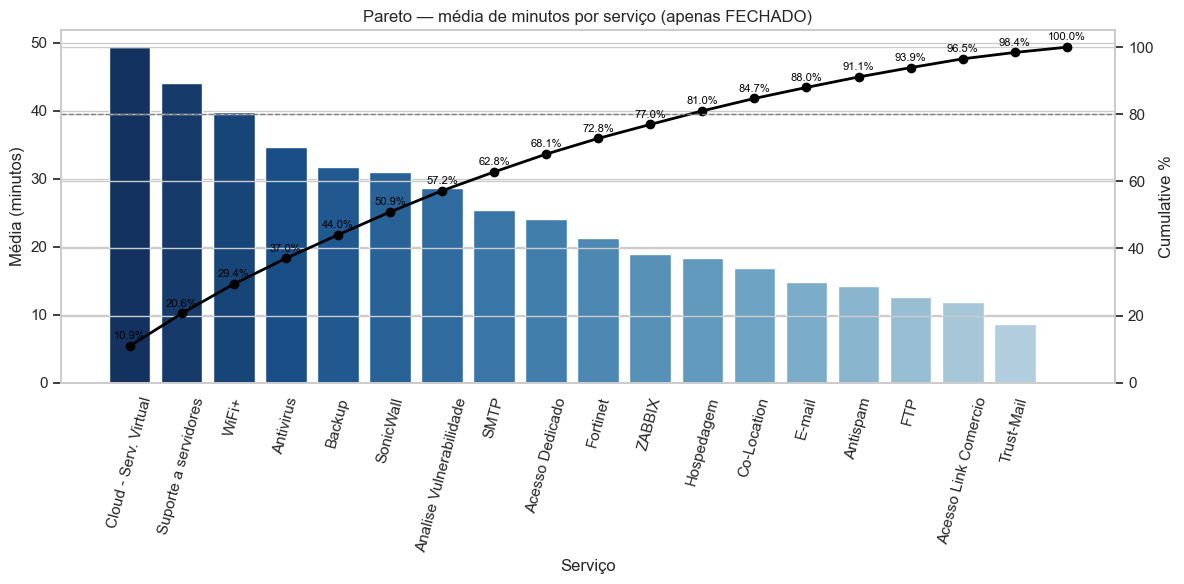

In [8]:
# Pareto em tons de azul degradê (apenas FECHADO, não altera `df`)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set(style='whitegrid')

# Reusar `tabela_media_por_servico` se existir, senão recalcular rapidamente a partir do arquivo bruto (filtrando FECHADO)
try:
    df_pareto = tabela_media_por_servico.copy()
except NameError:
    df_raw = pd.read_excel('Result_28.xlsx')
    if 'status_cliente' in df_raw.columns:
        df_raw = df_raw[df_raw['status_cliente'] == 'FECHADO']
    if 'duracao_minutos_total_por_ticket' in df_raw.columns:
        df_raw['duracao_td'] = pd.to_timedelta(df_raw['duracao_minutos_total_por_ticket'], errors='coerce')
    else:
        df_raw['duracao'] = df_raw['duracao'].fillna('00:00:00')
        df_raw['duracao_td'] = pd.to_timedelta(df_raw['duracao'], errors='coerce')
    ticket_for_avg = df_raw.groupby('id_ticket').agg({'servico':'first','duracao_td':'sum'}).reset_index()
    ticket_for_avg['duracao_minutos'] = ticket_for_avg['duracao_td'].dt.total_seconds() / 60
    tabela_total_e_qtd = ticket_for_avg.groupby('servico', dropna=False).agg(
        total_minutos=('duracao_minutos','sum'),
        qtd_tickets=('id_ticket','nunique')
    ).reset_index()
    tabela_total_e_qtd['media_minutos'] = tabela_total_e_qtd['total_minutos'] / tabela_total_e_qtd['qtd_tickets']
    df_pareto = tabela_total_e_qtd[['servico','media_minutos']]

# Preparar dados: ordenar por média decrescente
df_pareto = df_pareto.sort_values('media_minutos', ascending=False).reset_index(drop=True)
if df_pareto.empty:
    print('Nenhum dado disponível para plotagem.')
else:
    df_pareto['cumsum_pct'] = df_pareto['media_minutos'].cumsum() / df_pareto['media_minutos'].sum() * 100

    fig, ax1 = plt.subplots(figsize=(12,6))

    # Gerar paleta azul degradê (mais escuro para maiores valores)
    n = len(df_pareto)
    cmap = plt.cm.Blues
    colors = [cmap(0.3 + 0.7*(i/(n-1))) for i in range(n)][::-1]  # inverte para cores mais escuras nas maiores barras

    sns.barplot(data=df_pareto, x='servico', y='media_minutos', palette=colors, ax=ax1)
    ax1.set_xlabel('Serviço')
    ax1.set_ylabel('Média (minutos)')
    ax1.set_title('Pareto — média de minutos por serviço (apenas FECHADO)')
    ax1.tick_params(axis='x', rotation=75)

    ax2 = ax1.twinx()
    ax2.plot(range(len(df_pareto)), df_pareto['cumsum_pct'], color='black', marker='o', linewidth=2)
    ax2.set_ylabel('Cumulative %')
    ax2.set_ylim(0, 105)
    ax2.axhline(80, color='gray', linestyle='--', linewidth=1)

    # Anotações de percentual acumulado
    for i, pct in enumerate(df_pareto['cumsum_pct']):
        ax2.text(i, pct + 2, f"{pct:.1f}%", color='black', ha='center', fontsize=8)

    plt.tight_layout()
    plt.show()


In [9]:
# Contagem de tickets por colaborador (apenas FECHADO; não altera `df`)
# Conta tickets únicos por colaborador considerando apenas tickets com status FECHADO
if 'status_cliente' in df.columns:
    collab_closed = (
        df[df['status_cliente'] == 'FECHADO']
          .assign(_colab = df['colaborador'].fillna('Indefinido'))
          .groupby('_colab')['id_ticket']
          .nunique()
          .reset_index()
          .rename(columns={'_colab':'colaborador','id_ticket':'qtd_tickets'})
          .sort_values('qtd_tickets', ascending=False)
          .reset_index(drop=True)
    )
    print('Quantidade de tickets por colaborador (status FECHADO):')
    print(collab_closed)
else:
    # Se não houver coluna de status, assume todos os registros
    collab_closed = (
        df.assign(_colab = df['colaborador'].fillna('Indefinido'))
          .groupby('_colab')['id_ticket']
          .nunique()
          .reset_index()
          .rename(columns={'_colab':'colaborador','id_ticket':'qtd_tickets'})
          .sort_values('qtd_tickets', ascending=False)
          .reset_index(drop=True)
    )
    print('Quantidade de tickets por colaborador (todos os registros — coluna status inexistente):')
    print(collab_closed)

# Variável disponível: `collab_closed`

Quantidade de tickets por colaborador (status FECHADO):
   colaborador  qtd_tickets
0        Lucas         3757
1       Thiago         3470
2        Tiago         2433
3       Danilo         2078
4        Vitor         1797
..         ...          ...
72      3 - RR            1
73     3 - RP2            1
74        João            1
75     Jéssica            1
76     Laryssa            1

[77 rows x 2 columns]


In [10]:
df_filtrado = df.to_excel('dados_filtrados.xlsx', index=False)